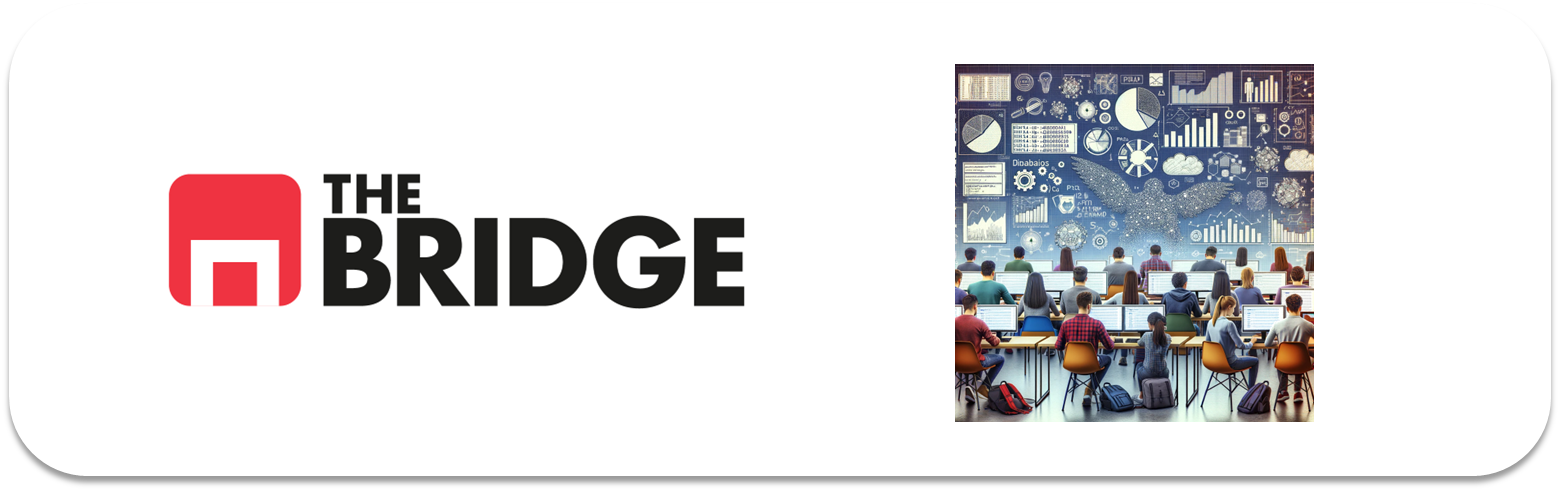

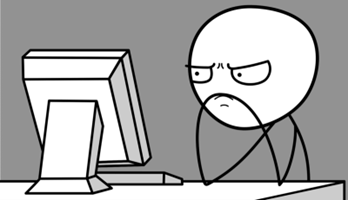

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns  

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [17]:
df_advert = pd.read_csv("./data/advertising_ml.csv")
df_advert.head()
  

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [18]:
df_advert.info()  

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 78.3 KB


In [19]:
df_advert.describe()

,Daily Time Spent on Site,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,55000.000080,180.000100,0.481000,0.50000
std,15.853615,13414.634022,43.902339,0.499889,0.50025
min,32.600000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,65470.635000,218.792500,1.000000,1.00000
max,91.430000,79484.800000,269.960000,1.000000,1.00000


Basado en la exploracion inical, no es necesario limpiar los datos mas alla de tipear mejor las columnas

### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

- clasificación clica/no clica
- supervisado
- Clicked on ad

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [20]:
# Cardinalidad de cada columna
print("Cardinalidad y tipo de cada columna:")
print("-" * 60)
for col in df_advert.columns:
    print(f"{col:<30} | únicos: {df_advert[col].nunique():<6} | tipo: {df_advert[col].dtype}")

Cardinalidad y tipo de cada columna:
------------------------------------------------------------
Daily Time Spent on Site       | únicos: 900    | tipo: float64
Age                            | únicos: 83     | tipo: str
Area Income                    | únicos: 1000   | tipo: float64
Daily Internet Usage           | únicos: 966    | tipo: float64
Ad Topic Line                  | únicos: 1000   | tipo: str
City                           | únicos: 969    | tipo: str
Male                           | únicos: 2      | tipo: int64
Country                        | únicos: 237    | tipo: str
Timestamp                      | únicos: 1000   | tipo: str
Clicked on Ad                  | únicos: 2      | tipo: int64


| Columna | Descripción | Tipo pandas | Clasificación |
|---------|-------------|-------------|---------------|
| `Daily Time Spent on Site` | Tiempo medio diario que el usuario pasa en el sitio (minutos) | float64 | **Numérica continua** |
| `Age` | Edad del usuario — contiene texto mezclado, necesita limpieza | str | **Numérica discreta** (sucia) |
| `Area Income` | Ingreso medio de la zona geográfica del usuario | float64 | **Numérica continua** |
| `Daily Internet Usage` | Minutos diarios de uso de internet del usuario | float64 | **Numérica continua** |
| `Ad Topic Line` | Título del anuncio mostrado | object | **Categórica** (alta cardinalidad) |
| `City` | Ciudad del usuario | object | **Categórica** (alta cardinalidad) |
| `Male` | Género del usuario: 1 = hombre, 0 = mujer | int64 | **Categórica binaria** |
| `Country` | País del usuario | object | **Categórica** |
| `Timestamp` | Momento en que el usuario interactuó con el anuncio | object | **Fecha/hora** |
| `Clicked on Ad` | Si el usuario hizo clic en el anuncio: 1 = sí, 0 = no → **TARGET** | int64 | **Categórica binaria** |

### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [21]:
# La columna Age tiene valores mixtos: "35 years", "35 años", "35", etc.
# Extraemos solo los dígitos en todos los casos
df_advert['Age'] = df_advert['Age'].str.extract(r'(\d+)').astype(int)

print("Tipo después de limpiar:", df_advert['Age'].dtype)
print(df_advert['Age'].describe())
df_advert[['Age']].head(10)

Tipo después de limpiar: int64
count    1000.000000
mean       36.009000
std         8.785562
min        19.000000
25%        29.000000
50%        35.000000
75%        42.000000
max        61.000000
Name: Age, dtype: float64


,Age
0,35
1,31
2,26
3,29
4,35
5,23
6,33
7,48
8,30
9,20


### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [22]:
from sklearn.model_selection import train_test_split

X = df_advert.drop(columns=['Clicked on Ad'])
y = df_advert['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(df_advert)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(df_advert)*100:.0f}%)")

Train: 800 filas (80%)
Test:  200 filas (20%)


### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

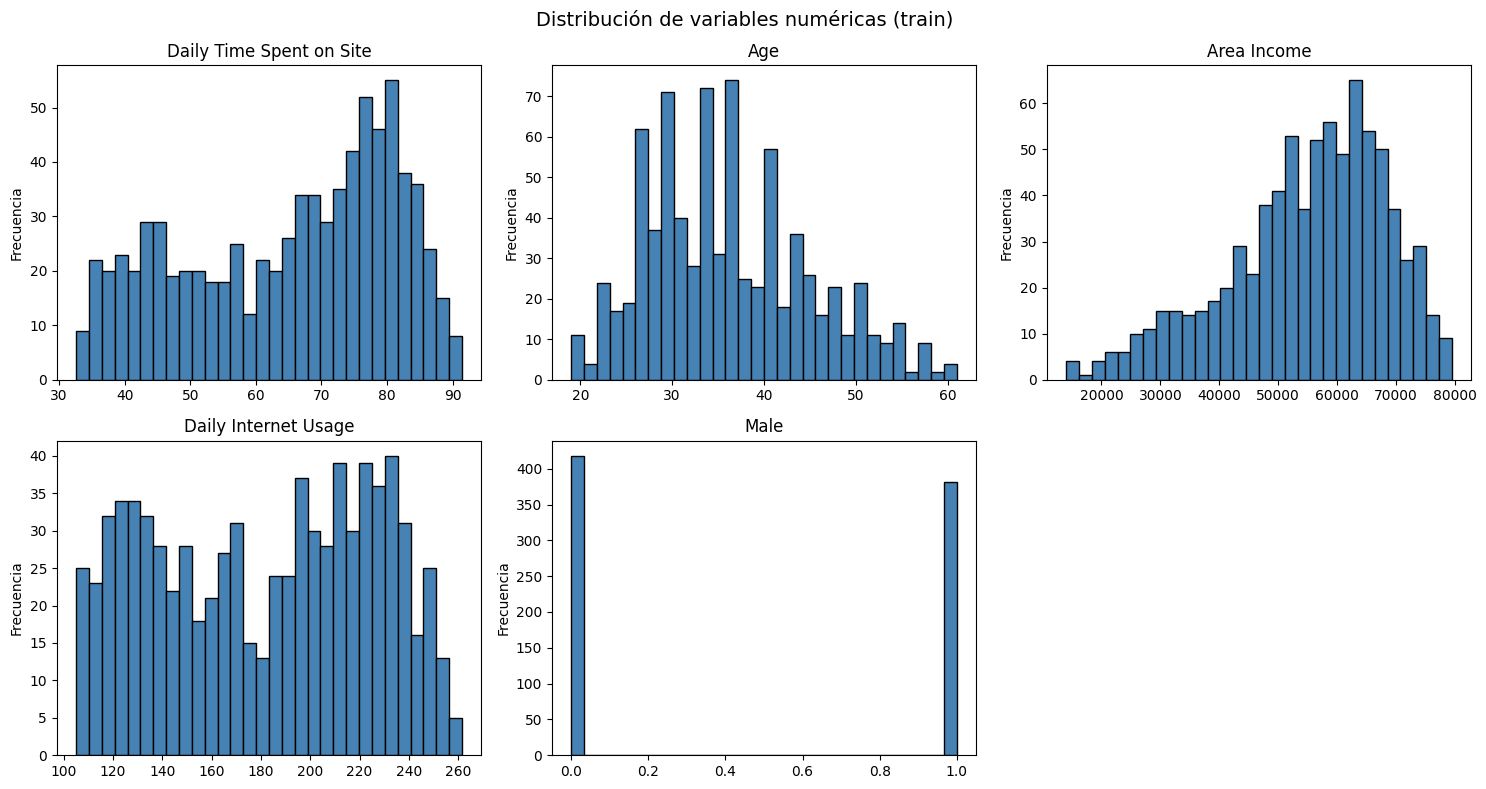

In [23]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(X_train[col], bins=30, edgecolor='black', color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas (train)', fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

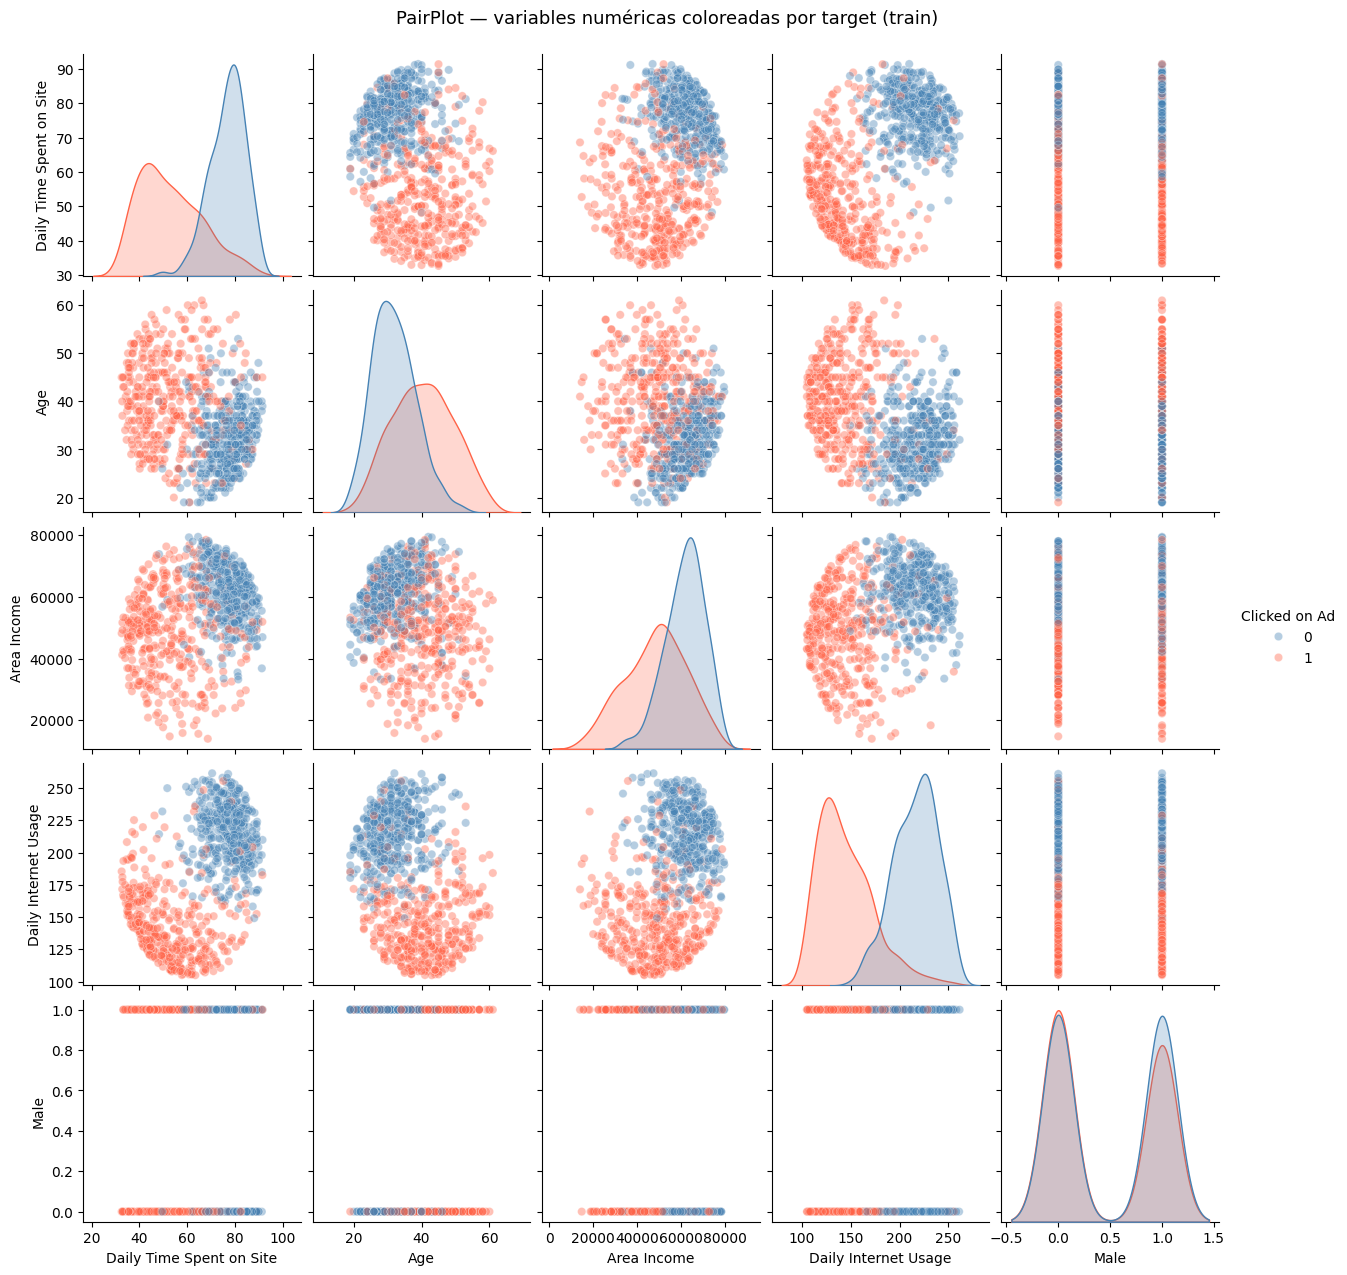

In [24]:
# Unimos X_train numérico con y_train para poder usar hue con el target
train_plot = X_train.select_dtypes(include='number').copy()
train_plot['Clicked on Ad'] = y_train.values

sns.pairplot(train_plot, hue='Clicked on Ad', palette={0: 'steelblue', 1: 'tomato'},
             plot_kws={'alpha': 0.4}, diag_kind='kde')
plt.suptitle('PairPlot — variables numéricas coloreadas por target (train)', y=1.02, fontsize=13)
plt.show()

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [25]:
# Análisis de la diagonal principal (KDE por clase):
# - Daily Time Spent on Site : distribuciones muy separadas → buena feature
# - Age                      : distribuciones bien separadas → buena feature
# - Area Income              : distribuciones bien separadas → buena feature
# - Daily Internet Usage     : distribuciones muy separadas → buena feature
# - Male                     : distribuciones casi idénticas (variable binaria) → poca capacidad predictiva → DESCARTADA

features_selected = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

X_train_sel = X_train[features_selected]
X_test_sel  = X_test[features_selected]

print("Features seleccionadas:", features_selected)
print(f"Shape train: {X_train_sel.shape}")
print(f"Shape test:  {X_test_sel.shape}")

Features seleccionadas: ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']
Shape train: (800, 4)
Shape test:  (200, 4)
